# ER graph: SHD vs update budget for CD_A and CD_A_epoch

这个 notebook 只比较两个算法：

- `CD_A`: `dag_coordinate_descent_l0`
- `CD_A_epoch`: `dag_coordinate_descent_l0_epoch`

关键点：一个 `CD_A_epoch` 的 epoch 包含

- `d(d-1)/2` 次非对角 pair 更新
- `d` 次对角更新

所以总共是 `d(d+1)/2` 次底层 update。为了公平比较，这里把横轴统一成 **update budget**，而不是直接拿 iter 和 epoch 混着比。

底层代码已经支持保存每个 update 后的图历史，因此每个 trial / algorithm 只需要跑一次到 `max(update_budgets)`，再直接读取历史计算 SHD。

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'synthetic_dataset.py').exists() and (candidate / 'coordinate_descent').exists():
            return candidate
    raise RuntimeError('Cannot locate repo root from current working directory.')


ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from synthetic_dataset import SyntheticDataset
from coordinate_descent.coordinate0 import (
    dag_coordinate_descent_l0,
    dag_coordinate_descent_l0_epoch,
)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

print('ROOT =', ROOT)

c:\Users\super\DAG\experiments\notebooks\test
ROOT = C:\Users\super\DAG


In [2]:
def make_update_budgets(max_budget=20000):
    early = list(range(1, 101))
    middle = list(range(200, 2001, 200))
    late = np.unique(np.geomspace(2500, max_budget, 18).astype(int)).tolist()
    return sorted(set(early + middle + late + [max_budget]))


CONFIG = {
    'd': 30,
    'n': 20000,
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'B_scale': 1.0,
    'threshold': 0.05,
    'lambda_l0': 0.2,
    'n_trials': 5,
    'master_seed': 20260405,
    'update_budgets': make_update_budgets(max_budget=300000),
    'save_results': True,
}

UPDATES_PER_EPOCH = CONFIG['d'] * (CONFIG['d'] + 1) // 2
MAX_UPDATE_BUDGET = max(CONFIG['update_budgets'])
MAX_EPOCHS = int(np.ceil(MAX_UPDATE_BUDGET / UPDATES_PER_EPOCH))

print('updates_per_epoch =', UPDATES_PER_EPOCH)
print('max_update_budget =', MAX_UPDATE_BUDGET)
print('max_epochs_for_CD_A_epoch =', MAX_EPOCHS)
CONFIG

updates_per_epoch = 465
max_update_budget = 300000
max_epochs_for_CD_A_epoch = 646


{'d': 30,
 'n': 20000,
 'degree': 2.0,
 'noise_type': 'gaussian_nv',
 'B_scale': 1.0,
 'threshold': 0.05,
 'lambda_l0': 0.2,
 'n_trials': 5,
 'master_seed': 20260405,
 'update_budgets': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  200,
  400,
  600,
  800,
  1000,
  1200,
  1400,
  1600,
  1800,
  2000,
  2500,
  3313,
  4390,
  5819,
  7711,
  10220,
  13544,
  17950,
  23789,
  31527,
  41781,
  55372,
  73383,
  97252,
  128886,
  170809,
  2263

In [3]:
def weight_to_binary_adj(W, threshold=0.0):
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def shd_score(G_true, G_est):
    G_true = np.asarray(G_true, dtype=int)
    G_est = np.asarray(G_est, dtype=int)
    return int(np.sum(np.abs(G_true - G_est)))


def make_er_trial(data_seed, cfg):
    dataset = SyntheticDataset(
        n=cfg['n'],
        d=cfg['d'],
        graph_type='ER',
        degree=cfg['degree'],
        noise_type=cfg['noise_type'],
        B_scale=cfg['B_scale'],
        seed=int(data_seed),
    )
    X = dataset.X
    S = X.T @ X / X.shape[0]
    G_true = weight_to_binary_adj(dataset.B, threshold=0.0)
    return dataset, S, G_true


def run_cd_a_full_history(S, max_budget, seed, cfg):
    return dag_coordinate_descent_l0(
        S=S,
        T=int(max_budget),
        seed=int(seed),
        threshold=cfg['threshold'],
        lambda_l0=cfg['lambda_l0'],
        return_history=True,
        return_graph_history=True,
    )


def run_cd_a_epoch_full_history(S, max_budget, seed, cfg):
    updates_per_epoch = cfg['d'] * (cfg['d'] + 1) // 2
    max_epochs = int(np.ceil(max_budget / updates_per_epoch))
    return dag_coordinate_descent_l0_epoch(
        S=S,
        n_epochs=max_epochs,
        seed=int(seed),
        threshold=cfg['threshold'],
        lambda_l0=cfg['lambda_l0'],
        tol=1e-4,
        patience=max_epochs + 1,
        min_epochs=max_epochs + 1,
        verbose=False,
        return_graph_history=True,
        graph_history_granularity='update',
    )


ALGORITHM_RUNNERS = {
    'CD_A': run_cd_a_full_history,
    'CD_A_epoch': run_cd_a_epoch_full_history,
}

ALGORITHM_ORDER = ['CD_A', 'CD_A_epoch']
ALGORITHM_COLORS = {
    'CD_A': 'steelblue',
    'CD_A_epoch': 'seagreen',
}

In [4]:
rng = np.random.default_rng(CONFIG['master_seed'])
trial_seeds = rng.integers(low=0, high=10**9, size=CONFIG['n_trials'])

rows = []
run_rows = []

for trial_id, data_seed in enumerate(trial_seeds, start=1):
    dataset, S, G_true = make_er_trial(int(data_seed), CONFIG)
    print(f'[trial {trial_id:02d}/{CONFIG["n_trials"]}] seed={int(data_seed)} | true_edges={int(G_true.sum())}')

    for algorithm in ALGORITHM_ORDER:
        runner = ALGORITHM_RUNNERS[algorithm]
        t0 = time.perf_counter()
        A_est, G_final, final_obj, history, graph_history = runner(S, MAX_UPDATE_BUDGET, int(data_seed), CONFIG)
        t1 = time.perf_counter()

        run_rows.append({
            'trial_id': trial_id,
            'data_seed': int(data_seed),
            'algorithm': algorithm,
            'history_len': int(len(history)),
            'graph_history_len': int(len(graph_history)),
            'full_run_runtime_sec': float(t1 - t0),
            'final_objective': float(final_obj),
            'final_edges': int(np.sum(G_final)),
        })

        effective_max_budget = min(MAX_UPDATE_BUDGET, len(graph_history))
        for budget in CONFIG['update_budgets']:
            eff_budget = min(int(budget), int(effective_max_budget))
            G_t = np.asarray(graph_history[eff_budget - 1], dtype=int)

            # score lookup
            if algorithm == 'CD_A':
                # history is per-step, length == T
                score_t = float(history[eff_budget - 1])
            else:
                # CD_A_epoch: history is per-epoch
                epoch_idx = min((eff_budget - 1) // UPDATES_PER_EPOCH, len(history) - 1)
                score_t = float(history[epoch_idx])

            rows.append({
                'trial_id': trial_id,
                'data_seed': int(data_seed),
                'algorithm': algorithm,
                'update_budget': int(budget),
                'effective_update_budget': int(eff_budget),
                'stopped_early': int(eff_budget < int(budget)),
                'shd': shd_score(G_true, G_t),
                'score': score_t,
                'n_edges_true': int(G_true.sum()),
                'n_edges_est': int(np.sum(G_t)),
            })

df = pd.DataFrame(rows)
df_runs = pd.DataFrame(run_rows)

display(df.head())
display(df_runs)

[trial 01/5] seed=218858081 | true_edges=27
[trial 02/5] seed=457189129 | true_edges=38
[trial 03/5] seed=312377554 | true_edges=35
[trial 04/5] seed=56581769 | true_edges=33
[trial 05/5] seed=514544373 | true_edges=35


,trial_id,data_seed,algorithm,update_budget,effective_update_budget,stopped_early,shd,score,n_edges_true,n_edges_est
0,1,218858081,CD_A,1,1,0,27,671.343682,27,0
1,1,218858081,CD_A,2,2,0,27,671.343682,27,0
2,1,218858081,CD_A,3,3,0,27,671.343682,27,0
3,1,218858081,CD_A,4,4,0,28,670.628862,27,1
4,1,218858081,CD_A,5,5,0,28,670.628862,27,1


,trial_id,data_seed,algorithm,history_len,graph_history_len,full_run_runtime_sec,final_objective,final_edges
0,1,218858081,CD_A,300000,300000,118.898878,54.626515,31
1,1,218858081,CD_A_epoch,646,300390,97.140095,54.721527,31
2,2,457189129,CD_A,300000,300000,123.985699,57.344980,53
3,2,457189129,CD_A_epoch,646,300390,98.919270,56.220508,40
4,3,312377554,CD_A,300000,300000,123.017766,56.168520,40
5,3,312377554,CD_A_epoch,646,300390,98.211301,58.142897,39
6,4,56581769,CD_A,300000,300000,120.135785,58.997596,31
7,4,56581769,CD_A_epoch,646,300390,98.785730,57.632780,40
8,5,514544373,CD_A,300000,300000,120.800546,54.514419,41
9,5,514544373,CD_A_epoch,646,300390,98.200131,54.844401,33


In [5]:
summary = (
    df.groupby(['algorithm', 'update_budget'], as_index=False)
      .agg(
          shd_mean=('shd', 'mean'),
          shd_std=('shd', 'std'),
          shd_min=('shd', 'min'),
          shd_max=('shd', 'max'),
          score_mean=('score', 'mean'),
          score_std=('score', 'std'),
          effective_update_budget_mean=('effective_update_budget', 'mean'),
          stopped_early_rate=('stopped_early', 'mean'),
      )
)

best_by_alg = (
    summary.loc[summary.groupby('algorithm')['shd_mean'].idxmin()]
           .sort_values(['shd_mean', 'algorithm'])
           .reset_index(drop=True)
)

display(summary.head(12))
display(best_by_alg)

,algorithm,update_budget,shd_mean,shd_std,shd_min,shd_max,score_mean,score_std,effective_update_budget_mean,stopped_early_rate
0,CD_A,1,33.8,4.381780,27,38,723.071224,285.293279,1.0,0.0
1,CD_A,2,33.8,4.381780,27,38,723.071224,285.293279,2.0,0.0
2,CD_A,3,34.0,4.527693,27,38,722.662435,285.956984,3.0,0.0
3,CD_A,4,34.6,4.449719,28,38,713.733420,299.319259,4.0,0.0
4,CD_A,5,34.6,4.449719,28,38,704.812173,300.015244,5.0,0.0
5,CD_A,6,35.2,4.438468,29,39,701.736446,300.775446,6.0,0.0
6,CD_A,7,35.0,4.636809,29,39,690.816475,317.524599,7.0,0.0
7,CD_A,8,35.2,4.816638,29,39,690.752811,317.544943,8.0,0.0
8,CD_A,9,35.2,4.494441,29,39,685.145890,311.048362,9.0,0.0
9,CD_A,10,35.4,4.159327,30,39,684.728508,311.081623,10.0,0.0


,algorithm,update_budget,shd_mean,shd_std,shd_min,shd_max,score_mean,score_std,effective_update_budget_mean,stopped_early_rate
0,CD_A_epoch,97252,29.0,4.358899,24,34,56.317046,1.564025,97252.0,0.0
1,CD_A,170809,30.0,10.606602,20,47,56.337052,1.900735,170809.0,0.0


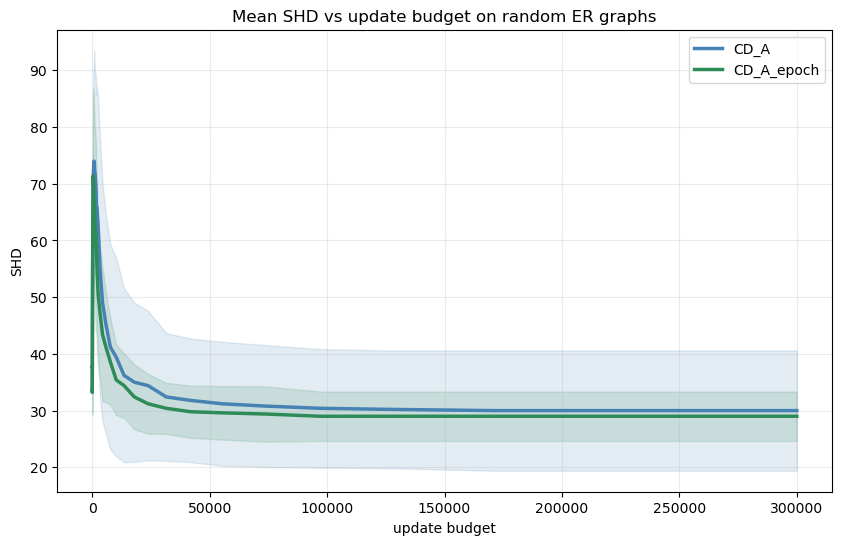

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for algorithm in ALGORITHM_ORDER:
    sub = summary[summary['algorithm'] == algorithm].sort_values('update_budget')
    x = sub['update_budget'].to_numpy()
    y = sub['shd_mean'].to_numpy()
    yerr = np.nan_to_num(sub['shd_std'].to_numpy(), nan=0.0)
    color = ALGORITHM_COLORS[algorithm]

    ax.plot(x, y, color=color, linewidth=2.5, label=algorithm)
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15)

ax.set_title('Mean SHD vs update budget on random ER graphs')
ax.set_xlabel('update budget')
ax.set_ylabel('SHD')
ax.legend()
plt.show()

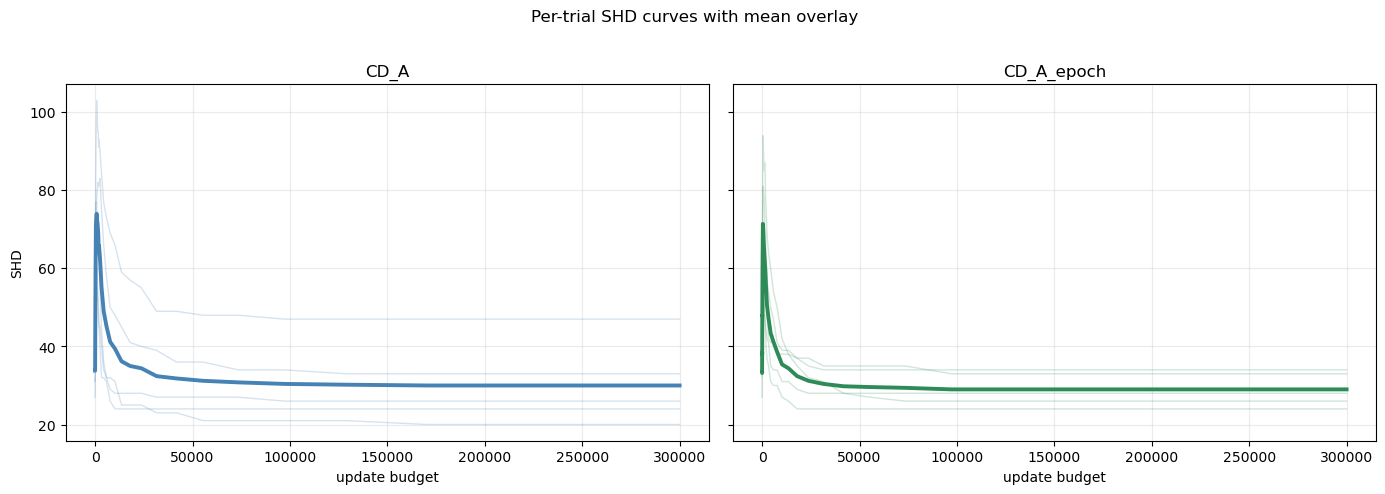

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

for ax, algorithm in zip(axes, ALGORITHM_ORDER):
    color = ALGORITHM_COLORS[algorithm]
    trial_sub = df[df['algorithm'] == algorithm].sort_values(['trial_id', 'update_budget'])
    for trial_id, one_trial in trial_sub.groupby('trial_id'):
        ax.plot(
            one_trial['update_budget'],
            one_trial['shd'],
            color=color,
            alpha=0.22,
            linewidth=1.0,
        )

    mean_sub = summary[summary['algorithm'] == algorithm].sort_values('update_budget')
    ax.plot(
        mean_sub['update_budget'],
        mean_sub['shd_mean'],
        color=color,
        linewidth=2.8,
    )
    ax.set_title(algorithm)
    ax.set_xlabel('update budget')

axes[0].set_ylabel('SHD')
fig.suptitle('Per-trial SHD curves with mean overlay', y=1.02)
fig.tight_layout()
plt.show()

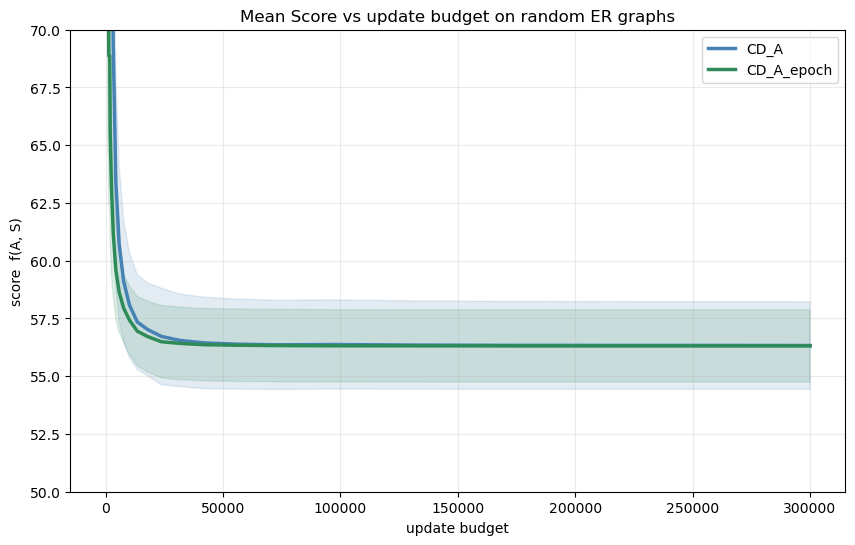

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for algorithm in ALGORITHM_ORDER:
    sub = summary[summary['algorithm'] == algorithm].sort_values('update_budget')
    x = sub['update_budget'].to_numpy()
    y = sub['score_mean'].to_numpy()
    yerr = np.nan_to_num(sub['score_std'].to_numpy(), nan=0.0)
    color = ALGORITHM_COLORS[algorithm]

    ax.plot(x, y, color=color, linewidth=2.5, label=algorithm)
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15)

ax.set_title('Mean Score vs update budget on random ER graphs')
ax.set_xlabel('update budget')
ax.set_ylabel('score  f(A, S)')
ax.set_ylim(50, 70)
ax.legend()
plt.show()

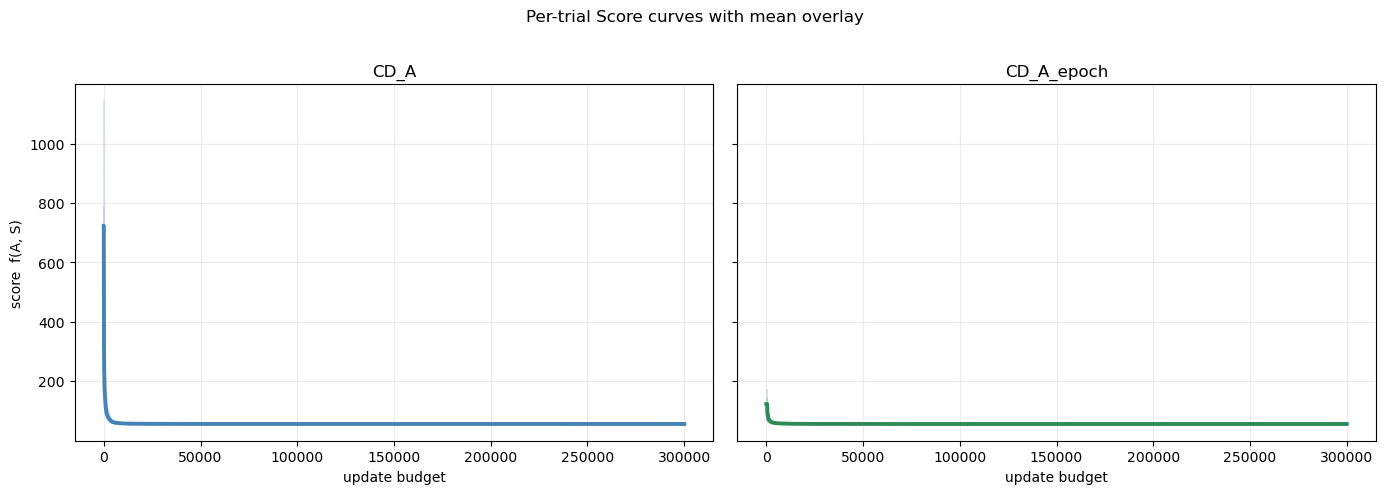

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

for ax, algorithm in zip(axes, ALGORITHM_ORDER):
    color = ALGORITHM_COLORS[algorithm]
    trial_sub = df[df['algorithm'] == algorithm].sort_values(['trial_id', 'update_budget'])
    for trial_id, one_trial in trial_sub.groupby('trial_id'):
        ax.plot(
            one_trial['update_budget'],
            one_trial['score'],
            color=color,
            alpha=0.22,
            linewidth=1.0,
        )

    mean_sub = summary[summary['algorithm'] == algorithm].sort_values('update_budget')
    ax.plot(
        mean_sub['update_budget'],
        mean_sub['score_mean'],
        color=color,
        linewidth=2.8,
    )
    ax.set_title(algorithm)
    ax.set_xlabel('update budget')

axes[0].set_ylabel('score  f(A, S)')
fig.suptitle('Per-trial Score curves with mean overlay', y=1.02)
fig.tight_layout()
plt.show()

In [10]:
if CONFIG['save_results']:
    outdir = ROOT / 'experiments' / 'results'
    outdir.mkdir(parents=True, exist_ok=True)
    tag = (
        f"er_cd_A_vs_epoch_shd_vs_update_budget_"
        f"d{CONFIG['d']}_n{CONFIG['n']}_deg{CONFIG['degree']}_trials{CONFIG['n_trials']}"
    )
    raw_path = outdir / f'{tag}_raw.csv'
    summary_path = outdir / f'{tag}_summary.csv'
    runs_path = outdir / f'{tag}_full_runs.csv'
    df.to_csv(raw_path, index=False)
    summary.to_csv(summary_path, index=False)
    df_runs.to_csv(runs_path, index=False)
    print('saved raw      ->', raw_path)
    print('saved summary  ->', summary_path)
    print('saved run info ->', runs_path)

saved raw      -> C:\Users\super\DAG\experiments\results\er_cd_A_vs_epoch_shd_vs_update_budget_d30_n20000_deg2.0_trials5_raw.csv
saved summary  -> C:\Users\super\DAG\experiments\results\er_cd_A_vs_epoch_shd_vs_update_budget_d30_n20000_deg2.0_trials5_summary.csv
saved run info -> C:\Users\super\DAG\experiments\results\er_cd_A_vs_epoch_shd_vs_update_budget_d30_n20000_deg2.0_trials5_full_runs.csv
